# Линейные модели

В рамках данного проекта ты реализуешь и обучишь линейную регрессию и логистическую регрессию — два фундаментальных алгоритма машинного обучения для решения задач регрессии и классификации. Начав с аналитического решения методом наименьших квадратов, ты перейдёшь к реализации алгоритма градиентного спуска для оптимизации параметров моделей. В процессе работы ты исследуешь такие важные аспекты, как регуляризация для борьбы с переобучением, стандартизация признаков и интерпретируемость коэффициентов моделей. Эти знания помогут тебе глубже понять принципы работы линейных моделей и научиться применять их для решения практических задач.

In [2]:
import numpy as np
from typing import Tuple

### Линейная регрессия
Линейная регрессия — один из самых простых и важных алгоритмов машинного обучения. Её идея — описать зависимость целевой переменной от признаков линейной функцией и подобрать параметры так, чтобы предсказания были максимально близки к наблюдениям.

Пусть у нас есть набор данных из $N$ объектов: для каждого объекта известны признаки $\mathbf{x}_i$ и целевое значение $y_i$. Мы хотим найти такую линейную функцию:

$$y = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$

где:
- $\mathbf{w} = (w_1, w_2, \ldots, w_n)^T$ — вектор весов (параметров модели);
- $b$ — свободный член (bias);
- $\mathbf{x} = (x_1, x_2, \ldots, x_n)^T$ — вектор признаков объекта.

![Бриллианты](../misc/images/diamonds.png)

Чтобы быстро перейти от теории к практике, возьмём реальный датасет о бриллиантах. Один из ключевых факторов цены — каратность. Для начала предположим простую модель с одним признаком:

$$y = w \cdot x + b + \varepsilon$$

где:
- $y$ — цена бриллианта;
- $x$ — каратность;
- $b$ — базовая цена (свободный член);
- $w$ — «цена» одного карата (коэффициент при признаке);
- $\varepsilon$ — шум (то, что модель не объясняет).

Чтобы по каратности предсказывать цену для новых камней, нужно оценить параметры $w$ и $b$ по историческим данным.

Один из способов — аналитическое решение через метод наименьших квадратов (МНК). В матричной записи это приводит к «нормальному уравнению»:

$$X^T (y - X\hat{w}) = 0$$
$$X^T X\hat{w} = {X}^T y$$
Если $X^T X$ обратима, то:
$$\hat{w} = (X^T X)^{-1} X^T y$$

#### Зачем начинать с аналитического решения?

Прежде чем перейти к градиентному спуску, полезно увидеть, что для простого случая линейной регрессии существует
**точное решение в замкнутой форме**. Это позволяет:
- получить эталонные значения параметров $w$ и $b$, с которыми потом можно сравнить результат градиентного спуска;
- убедиться, что ты правильно понимаешь постановку задачи и формат данных;
- прочувствовать, почему при большом числе признаков аналитический подход становится непрактичным.

## Задание 1. Аналитическое решение

В этом задании тебе требуется построить линейную модель для предсказания стоимости бриллианта на основе его каратности с помощью метода наименьших квадратов (МНК). Ты реализуешь аналитическое решение «вручную», используя матричные операции, а затем проверишь правильность своей реализации, сравнив результаты с библиотекой `sklearn`.

1. **Подготовка данных:**
   - Загрузи датасет из файла `datasets/diamonds.csv`.
   - Возьми один признак: каратность (`carat`) и целевую переменную: цену (`price`).
   - Сформируй матрицу признаков `X` размера $N \times 1$ и вектор ответов `y` размера $N$.

2. **Реализация аналитического решения (МНК):**
   - Добавь к `X` столбец единиц, чтобы учитывать свободный член $b$.
   - Вычисли $\hat{w}$ по формуле: $\hat{w} = (X^T X)^{-1} X^T y$.
   - Выведи полученные параметры модели: `b_v1` (свободный член) и `w_v1` (коэффициент при каратности).
   - Интерпретируй результаты: что означает полученное значение $w$? Какую цену будет иметь бриллиант с нулевой каратностью (параметр $b$)?

3. **Сравнение с `sklearn`:**
   - Обучи `LinearRegression` из `sklearn.linear_model` на тех же `X` и `y`.
   - Выведи полученные параметры модели: `b_v2` (свободный член) и `w_v2` (коэффициент при каратности).
   - Сравни коэффициенты: они должны совпасть или быть очень близкими (например, через `np.allclose`).

4. **Оценка качества и визуализация:**
   - Посчитай MAE (Mean Absolute Error, среднюю абсолютную ошибку) для аналитического решения.
   - Посчитай MAE для решения через `sklearn`.
   - Построй график: точки (реальные данные) и прямая регрессии (предсказания модели).

In [3]:
import pandas as pd

diamonds = pd.read_csv("..\datasets\diamonds.csv")

diamonds.head()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\edolg\AppData\Local\Temp\ipykernel_4900\1025749042.py:3: SyntaxWarning: invalid escape sequence '\d'
  diamonds = pd.read_csv("..\datasets\diamonds.csv")


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
import numpy as np

X = np.array(diamonds["carat"]).reshape(-1, 1)
y = np.array(diamonds["price"])

X = np.column_stack((np.ones(len(X)), X))

w = np.linalg.inv(X.T @ X) @ X.T @ y

b_v1, w_v1 = w

print("Свободный член:", b_v1)
print("Коэффициент при carat:", w_v1)

Свободный член: -2256.3605800454234
Коэффициент при carat: 7756.425617968449


Первое число - коэффициент при каратности - это коэффициент `w`, стоящий перед `x` в нашем уравнении цены бриллианта. Оно означает "цену" одного карата. Но в случае, если каратность равна 0, цена камня будет равно свободному члену `b`.

In [5]:
from sklearn.linear_model import LinearRegression

X_sklearn = diamonds[["carat"]]
y = diamonds["price"]

model = LinearRegression()
model.fit(X_sklearn, y)

w_v2 = model.coef_[0]
b_v2 = model.intercept_

print(f"Свободный член: {b_v2}")
print(f"Коэффициент при carat: {w_v2}")

Свободный член: -2256.3605800457585
Коэффициент при carat: 7756.42561796888


In [6]:
# Проверка
print(f"Коэффициенты совпадают? - {np.allclose([b_v1, w_v1], [b_v2, w_v2])}")

Коэффициенты совпадают? - True


In [7]:
from sklearn.metrics import mean_absolute_error

X = diamonds["carat"].to_numpy()

y_pred_analytic = b_v1 + w_v1*X
y_pred_sklearn = model.predict(X_sklearn)

mae_analytic = mean_absolute_error(y_pred_analytic, y)
mae_sklearn = mean_absolute_error(y_pred_sklearn, y)

print(f"MAE аналитического решения: {mae_analytic}")
print(f"MAE sklearn: {mae_sklearn}")

MAE аналитического решения: 1007.4632473569872
MAE sklearn: 1007.4632473570293


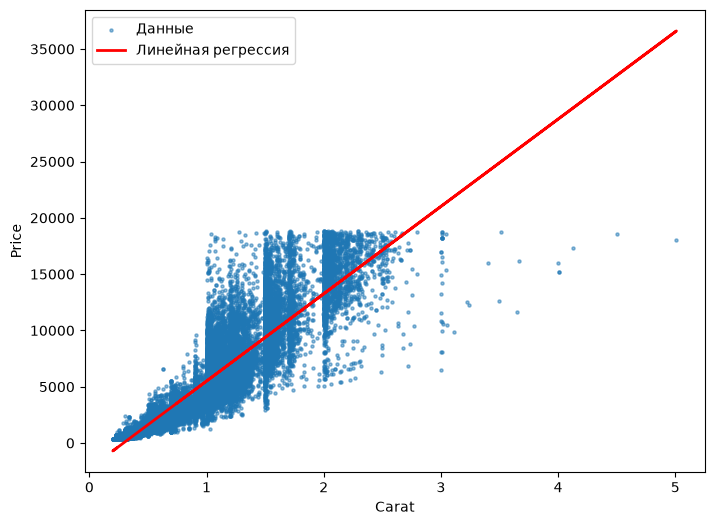

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(diamonds["carat"], y, s=5, alpha=0.5, label="Данные")

plt.plot(
  diamonds["carat"],
  y_pred_sklearn,
  color="red",
  linewidth=2,
  label="Линейная регрессия"
)

plt.xlabel("Carat")
plt.ylabel("Price")
plt.legend()
plt.show()

#### Почему аналитическое решение не используется на практике?

Ты только что получил точные параметры $w$ и $b$ одной операцией — казалось бы, задача решена. Но у формулы
$\hat{w} = (X^T X)^{-1} X^T y$ есть серьёзные ограничения:

- **Сложность вычислений**: обращение матрицы стоит $O(d^3)$, где $d$ — число признаков. При $d$ в десятки тысяч
  (текстовые или пиксельные признаки) это становится вычислительно неподъёмным.
- **Память**: нужно хранить матрицу $X^TX$ размера $d \times d$.
- **Численная нестабильность**: если признаки коррелируют, матрица $X^TX$ плохо обусловлена и обратная матрица
  даёт неточный результат.

#### Решение — градиентный спуск

Вместо того чтобы вычислять решение «за один шаг», градиентный спуск приближается к нему итеративно:
на каждой итерации мы чуть-чуть сдвигаем параметры в сторону, уменьшающую ошибку. Это масштабируется
на миллионы признаков и лежит в основе обучения нейронных сетей.

Основная идея: мы хотим минимизировать функцию потерь — среднеквадратичную ошибку (MSE):

$$
L(w, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

где предсказание модели:

$$
\hat{y}_i = b + w_1 x_{i1} + w_2 x_{i2} + \dots + w_d x_{id} = b + \mathbf{w}^\top \mathbf{x}_i
$$

Для минимизации функции потерь мы будем использовать её **градиент**.

Градиент — это вектор, составленный из частных производных функции.
Он показывает направление, в котором функция растёт быстрее всего.
Поэтому, чтобы двигаться к минимуму, нам нужно идти в **противоположную** сторону — против градиента.

Следовательно, обновлять параметры будем по такому правилу:

$$
b \leftarrow b - \alpha \cdot \frac{\partial L}{\partial b}
$$

$$
w_j \leftarrow w_j - \alpha \cdot \frac{\partial L}{\partial w_j}, \quad j = 1, \dots, d
$$

где $\alpha$ — шаг (learning rate).

## Задание 2. Градиент функции потерь

Чтобы реализовать градиентный спуск, нужно знать, в каком направлении изменять параметры модели. Для этого требуется вычислить градиент функции потерь — вектор частных производных по каждому параметру. Градиент показывает направление наибольшего роста функции, поэтому для минимизации мы движемся в противоположном направлении.

В этом задании тебе нужно вычислить градиент функции потерь $L$ для случая одного признака ($\hat{y}_i = b + w_1 x_i$).
Найди частные производные по $b$ и $w_1$. Запиши:

$$
\frac{\partial L}{\partial b}
=
-\frac{2}{N}
\sum_{i=1}^{N}
\left(y_i - b - w_1x_i\right).
$$

$$
\frac{\partial L}{\partial w_1}
=
-\frac{2}{N}
\sum_{i=1}^{N}
x_i\left(y_i - b - w_1x_i\right).
$$

## Задание 3. Обновление параметров

Теперь, когда ты знаешь, как вычисляется градиент функции потерь, можно перейти к практической реализации. В этом задании ты создашь класс `Gradient`, который инкапсулирует логику работы с градиентами и обновления параметров модели. Этот класс станет основой для реализации полного алгоритма градиентного спуска в следующем задании.

Класс будет содержать методы для предсказания, вычисления ошибки и обновления параметров согласно формулам градиентного спуска, которые ты вывел в предыдущем задании.

1. **Реализация класса `Gradient`:**
   - Напиши класс `Gradient()`, который при инициализации получает два вектора: `X` (признаки) и `Y` (целевая переменная).
   - Реализуй методы класса согласно их docstrings и аннотациям типов (type hints).
   - Обрати внимание на сигнатуры методов и их возвращаемые значения: `predict` возвращает массив предсказаний, `mse` возвращает число, `update` возвращает кортеж из двух элементов.

2. **Проверка работы методов:**
   - Инициализируй класс с данными `X`, `Y` из задания 1 (признак `carat` и целевая переменная `price`).
   - Задай начальные параметры (например, `w=0`, `b=0`).
   - Вызови `predict` и `mse` для проверки корректности работы методов.
   - Вызови `update` несколько раз (2–3 итераций) и покажи, как изменяются ошибка (MSE) и параметры `w`, `b` после каждого обновления.

In [9]:
class Gradient:
    """
    Класс для работы с градиентами и обновления параметров модели.
    
    При инициализации получает два вектора: X (признаки) и Y (целевая переменная).
    """
    def __init__(self, X: np.ndarray, Y: np.ndarray) -> None:
        """
        Инициализация класса.
        
        Parameters:
        -----------
        X : array-like
            Матрица признаков
        Y : array-like
            Вектор целевой переменной
        """
        self.X = np.array(X)
        self.Y = np.array(Y)

    def predict(self, w: np.ndarray, b: float) -> np.ndarray:
        """
        Вычисляет прогнозные значения модели.
        
        Parameters:
        -----------
        w : array-like
            Параметры модели (веса)
        b : float
            Свободный член (bias)
            
        Returns:
        --------
        prediction : array-like
            Прогнозные значения prediction = w * X + b
        """
        return w * self.X + b

    def mse(self, prediction: np.ndarray) -> float:
        """
        Вычисляет среднеквадратичную ошибку.
        
        Parameters:
        -----------
        prediction : array-like
            Предсказания модели
            
        Returns:
        --------
        mse : float
            Среднеквадратичная ошибка относительно Y
        """
        return np.mean((prediction - self.Y) ** 2)

    def update(self, w: np.ndarray, b: float, a: float = 0.01) -> Tuple[np.ndarray, float]:
        """
        Обновляет параметры модели согласно формулам градиентного спуска.
        
        Parameters:
        -----------
        w : array-like
            Текущие параметры модели (веса)
        b : float
            Текущий свободный член (bias)
        a : float, default=0.01
            Learning rate (шаг обучения)
            
        Returns:
        --------
        w_new : array-like
            Обновленные параметры w
        b_new : float
            Обновленный свободный член b
        """
        y_hat = self.predict(w, b)
        error = y_hat - self.Y

        dw = 2 * np.mean(error * self.X)
        db = 2 * np.mean(error)

        w_new = w - a * dw
        b_new = b - a * db

        return w_new, b_new
        

In [10]:
X = diamonds["carat"]
Y = diamonds["price"]
w = 0
b = 0

grad = Gradient(X, Y)

prediction = grad.predict(w, b)
mse = grad.mse(prediction)
new_w, new_b = grad.update(w, b)


print(f"Работа метода predict: {prediction}")
print(f"Работа метода mse: {mse}")
print(f"Работа метода update: {new_w, new_b}")

Работа метода predict: [0. 0. 0. ... 0. 0. 0.]
Работа метода mse: 31382248.015257694
Работа метода update: (np.float64(97.61740546903968), np.float64(78.65599443826474))


## Задание 4. Градиентный спуск

Теперь, когда у тебя есть класс `Gradient` с методами для обновления параметров, можно реализовать полный алгоритм градиентного спуска. В этом задании ты создашь класс `GradientDescent`, который наследуется от `Gradient` и автоматизирует процесс обучения модели: итеративно обновляет параметры, отслеживает историю обучения и останавливается по заданным критериям.

Важной особенностью реализации будет адаптивный learning rate: в процессе обучения learning rate будет уменьшаться, что позволяет сначала быстро приблизиться к минимуму, а затем точно настроить параметры модели.

1. **Реализация класса `GradientDescent`:**
   - Создай класс `GradientDescent(Gradient)`, который наследует все методы из `Gradient`.
   - Реализуй метод `optimize` согласно его docstrings и аннотациям типов (type hints).
   - Метод должен итеративно обновлять `w` и `b` с помощью метода `update`.
   - **Важно:** learning rate `a` должен уменьшаться в ходе обучения по формуле: $a_t = a_0 \cdot \frac{1}{1 + \text{decay} \cdot t}$, где $a_0$ — начальный learning rate, $t$ — номер итерации, $\text{decay} = 0.01$ — коэффициент затухания.
   - Критерии остановки:
     - Превышено количество итераций `num_iterations`.
     - Изменение MSE между итерациями меньше `stopping_threshold`.
   - Метод должен вернуть словарь с ключами: `'w'`, `'b'`, `'mse'`, `'history'` (список значений MSE на каждой итерации), `'iterations'` (количество выполненных итераций).

2. **Визуализация и анализ:**
   - Обучи модель на данных `X`, `Y` с разными значениями learning rate: `[0.0000001, 0.001, 1]`.
   - Для каждого learning rate построй график зависимости MSE от номера итерации.
   - На отдельном графике визуализируй финальные линии регрессии для разных learning rate.

3. **Сравнение с аналитическим решением:**
   - Сравни полученные градиентным спуском значения с аналитическим решением из Задания 1.
   - Визуализируй оба решения на одном графике.
   - Выведи значение MSE для лучшего результата.

In [11]:
class GradientDescent(Gradient):
    """
    Класс для реализации полного алгоритма градиентного спуска.
    
    Наследуется от класса Gradient и добавляет метод optimize для автоматизации
    процесса обучения модели с адаптивным learning rate.
    """
    def optimize(self, num_iterations: int, stopping_threshold: float = 0.001, 
                 a: float = 0.000001, w_init: float = 0, b_init: float = 0) -> dict:
        """
        Оптимизирует параметры модели с помощью градиентного спуска.
        
        Parameters:
        -----------
        num_iterations : int
            Максимальное количество итераций обучения.
        stopping_threshold : float, default=0.001
            Порог остановки: обучение прекращается, если изменение MSE между
            итерациями меньше этого значения.
        a : float, default=0.000001
            Начальный learning rate (будет уменьшаться в ходе обучения).
        w_init : float, default=0
            Начальное значение параметра w.
        b_init : float, default=0
            Начальное значение параметра b.
            
        Returns:
        --------
        result : dict
            Словарь с ключами:
            - 'w': np.ndarray — финальные параметры w;
            - 'b': float — финальный параметр b;
            - 'mse': float — финальное значение MSE;
            - 'history': list — список значений MSE на каждой итерации;
            - 'iterations': int — количество выполненных итераций.
            
        Note:
        -----
        Learning rate уменьшается по формуле: a_t = a_0 / (1 + decay * t),
        где decay = 0.01, t — номер итерации.
        """
        decay = 0.01
        w, b = w_init, b_init

        history = []
        prev_mse = float('inf')

        for t in range(num_iterations):

            at = a / (1 + decay * t)

            prediction = self.predict(w, b)
            mse = self.mse(prediction)
            history.append(mse)

            if abs(prev_mse - mse) < stopping_threshold:
                break

            prev_mse = mse

            w, b = self.update(w, b, at)

        return {
            'w': w,
            'b': b,
            'mse': mse,
            'history': history,
            'iterations': len(history)
        }

In [15]:
X = diamonds["carat"]
Y = diamonds["price"]

learning_rates = [0.0000001, 0.001, 1]

results = {}

for lr in learning_rates:
    gd = GradientDescent(X, Y)
    res = gd.optimize(num_iterations=5000, a=lr)
    results[lr] = res 

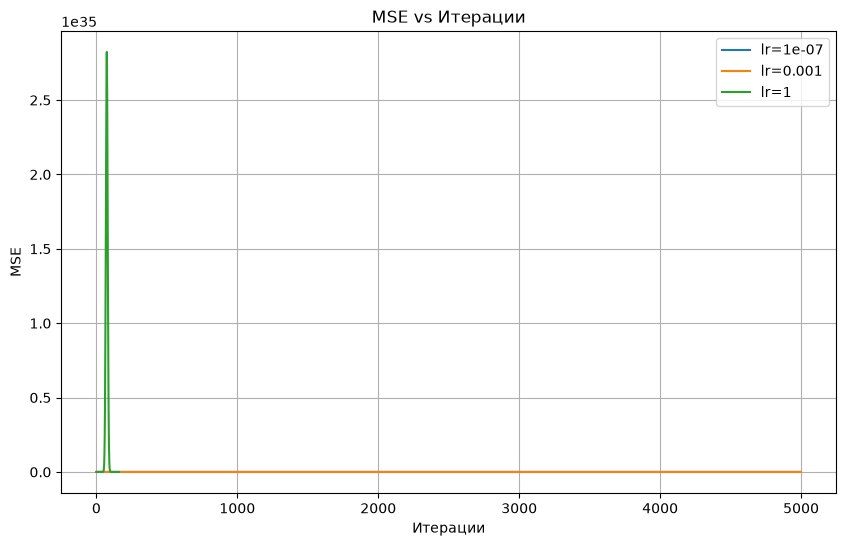

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    plt.plot(results[lr]['history'], label=f"lr={lr}")

plt.xlabel("Итерации")
plt.ylabel("MSE")
plt.title("MSE vs Итерации")
plt.legend()
plt.grid()
plt.show()

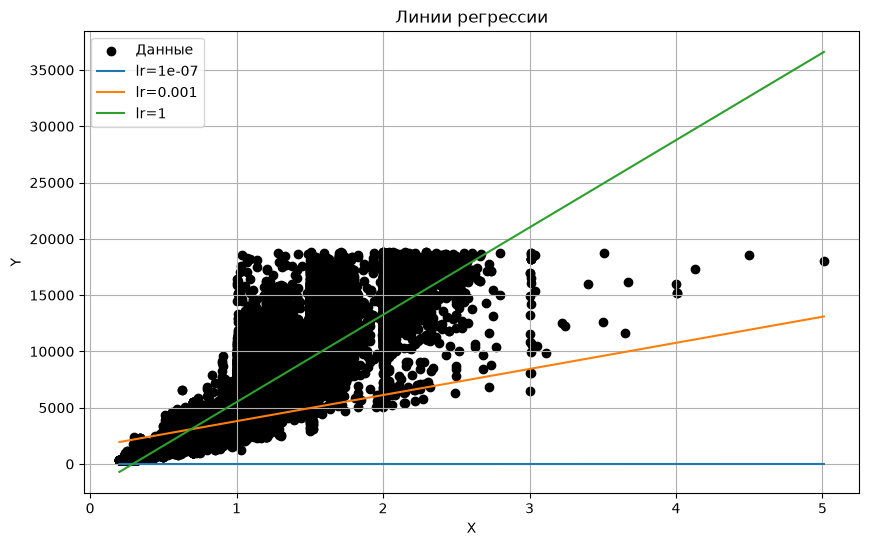

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, label="Данные", color="black")

x_line = np.linspace(min(X), max(X), 100)

for lr in learning_rates:
    w = results[lr]['w']
    b = results[lr]['b']
    y_line = w * x_line + b
    plt.plot(x_line, y_line, label=f"lr={lr}")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Линии регрессии")
plt.legend()
plt.grid()
plt.show()

In [21]:
x_mean = np.mean(X)
y_mean = np.mean(Y)

w_analytic = np.sum((X - x_mean)*(Y - y_mean)) / np.sum((X - x_mean) ** 2)
b_analytic = y_mean - w_analytic * x_mean

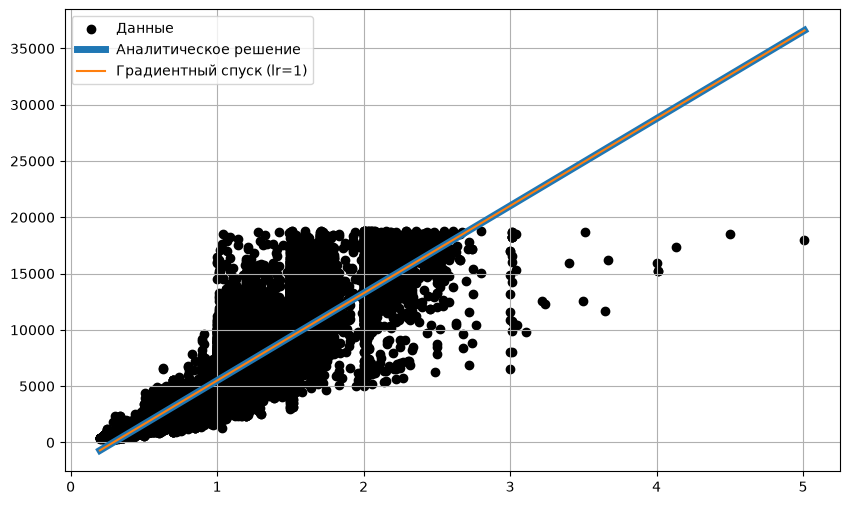

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color="black", label="Данные")

y_line_analytic = w_analytic*x_line + b_analytic
plt.plot(x_line, y_line_analytic, label="Аналитическое решение", linewidth=5)

best_lr = min(learning_rates, key=lambda lr: results[lr]['mse'])
w_best = results[best_lr]['w']
b_best = results[best_lr]['b']
y_line_best = w_best * x_line + b_best

plt.plot(x_line, y_line_best, label=f"Градиентный спуск (lr={best_lr})")

plt.legend()
plt.grid()
plt.show()

In [30]:
best_lr = min(learning_rates, key=lambda lr: results[lr]['mse'])
best_mse = results[best_lr]['mse']

print("Лучший learning rate:", best_lr)
print("MSE:", best_mse)


Лучший learning rate: 1
MSE: 2397955.0500379754


## Задание 5. Используем все данные

Попробуем улучшить результат предсказания цены бриллианта, используя все доступные признаки датасета (каратность,
огранка, цвет, чистота, глубина, таблица, размеры x, y, z).

1. **Загрузи данные и подготовь целевую переменную:**
   - Загрузи датасет из файла `datasets/diamonds.csv`.
   - Выдели целевую переменную `price` (вектор `y`) и все остальные столбцы как признаки (матрица `X`).

2. **Закодируй категориальные признаки:**
   - Столбцы `cut`, `color`, `clarity` — категориальные. Примени к ним `OneHotEncoder` (или `pd.get_dummies`).
   - После кодирования проверь, что в данных не осталось строковых столбцов.

3. **Раздели данные на обучающую и тестовую выборку:**
   - Используй `train_test_split` из `sklearn.model_selection` (80% train / 20% test, `random_state=21`).

4. **Стандартизируй числовые признаки:**
   - Примени `StandardScaler`: обучи (`.fit_transform`) на тренировочных данных, примени (`.transform`) к тестовым.
   - Важно: скейлер обучается **только** на обучающей выборке, чтобы не допускать утечки данных.

5. **Обучи модель и оцени качество:**
   - Обучи `SGDRegressor` из `sklearn.linear_model` на обучающей выборке.
   - Посчитай MAE и MSE на тестовой выборке.
   - Сравни с результатом модели только по каратности из Задания 1: улучшилось ли качество?

In [35]:
data = pd.read_csv("..\datasets\diamonds.csv")

X = data.drop(columns="price")
y = data["price"]

X.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\edolg\AppData\Local\Temp\ipykernel_4900\1176723625.py:1: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv("..\datasets\diamonds.csv")


,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75


In [36]:
y.head()

0    326
1    326
2    327
3    334
4    335
Name: price, dtype: int64

In [37]:
categorial_cols = ["cut", "color", "clarity"]

X_encoded = pd.get_dummies(X, columns=categorial_cols, drop_first=True)

X_encoded.dtypes[X_encoded.dtypes == "object"]

Series([], dtype: object)

In [38]:
X_encoded.head()

,Unnamed: 0,carat,depth,table,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,1,0.23,61.5,55.0,3.95,3.98,2.43,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,2,0.21,59.8,61.0,3.89,3.84,2.31,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,3,0.23,56.9,65.0,4.05,4.07,2.31,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,4,0.29,62.4,58.0,4.20,4.23,2.63,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,5,0.31,63.3,58.0,4.34,4.35,2.75,True,False,False,...,False,False,True,False,False,True,False,False,False,False


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=21)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = SGDRegressor(
    max_iter=5000,
    learning_rate="optimal",
    random_state=21
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 5174448878.249391
MSE: 1.0663696399628522e+21


По сравнению с моделью по кратности MAE уменьшилась в 2 раза и MSE примерно во столько же. Это говорит нам о том, что модель стала точнее.

## Задание 6. Ridge и Lasso регрессии

**Что такое регуляризация и зачем она нужна**

При обучении на многих признаках модель может «подстроиться» под шум в данных и плохо работать на новых примерах — это переобучение. Регуляризация ограничивает сложность модели, добавляя к функции потерь штраф за большие веса. Так мы заставляем модель не полагаться слишком сильно на отдельные признаки и лучше обобщать.

Два самых распространённых вида регуляризации в линейных моделях:

- **Ridge (L2-регуляризация)** добавляет штраф $\lambda \|w\|_2^2 = \lambda \sum_j w_j^2$. Все веса уменьшаются по величине, но остаются ненулевыми. Ridge устойчива к мультиколлинеарности (сильной связи между признаками) и часто улучшает качество на тесте.
- **Lasso (L1-регуляризация)** добавляет штраф $\lambda \|w\|_1 = \lambda \sum_j |w_j|$. Часть весов обнуляется — модель автоматически отбирает наиболее важные признаки. Lasso полезен для интерпретации и когда признаков много, а значимых мало.

Сила регуляризации задаётся гиперпараметром $\alpha$: чем больше $\alpha$, тем сильнее штраф и тем «проще» модель.

В этом задании ты сравнишь Ridge и Lasso с моделью без регуляризации и оценишь, насколько регуляризация помогает качеству на тех же данных про бриллианты.

1. **Обучи Ridge-модель:**
   - Используй `Ridge` из `sklearn.linear_model` с `alpha=0.01`.
   - Обучи на `X_train_scaled`, `y_train` из Задания 5.
   - Посчитай MAE и MSE на тестовой выборке.

2. **Обучи Lasso-модель:**
   - Используй `Lasso` из `sklearn.linear_model` с `alpha=0.01`.
   - Обучи на тех же данных.
   - Посчитай MAE и MSE на тестовой выборке.

3. **Сравни качество трёх моделей:**
   - Выведи MAE и MSE для SGDRegressor (Задание 5), Ridge и Lasso в одной таблице/выводе.
   - Улучшилось ли качество при использовании Ridge или Lasso? Насколько?

In [45]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

ridge = Ridge(alpha=0.01)
lasso = Lasso(alpha=0.01)

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)
lasso_pred = lasso.predict(X_test_scaled)

print("MAE, MSE для SGDRegressor")
print(mae)
print(mse)

print()
print("MAE, MSE для Ridge")
print("-"*30)
print(mean_absolute_error(y_test, ridge_pred))
print(mean_squared_error(y_test, ridge_pred))

print()
print("MAE, MSE для Lasso")
print("-"*30)
print(mean_absolute_error(y_test, lasso_pred))
print(mean_squared_error(y_test, lasso_pred))

MAE, MSE для SGDRegressor
5174448878.249391
1.0663696399628522e+21

MAE, MSE для Ridge
------------------------------
730.8602810750197
1220559.145222053

MAE, MSE для Lasso
------------------------------
730.853790559578
1220558.3594020691


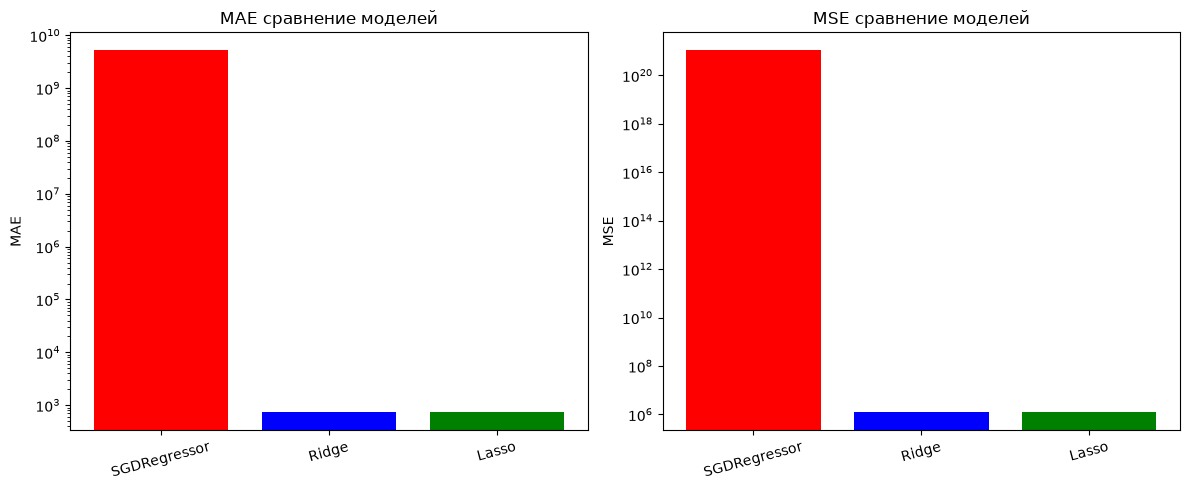

In [ ]:
models = ["SGDRegressor", "Ridge", "Lasso"]
mae_values = [
    mae,
    mean_absolute_error(y_test, ridge_pred),
    mean_absolute_error(y_test, lasso_pred)
]
mse_values = [
    mse,
    mean_squared_error(y_test, ridge_pred),
    mean_squared_error(y_test, lasso_pred)
]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(models, mae_values, color=["red", "blue", "green"])
plt.title("MAE сравнение моделей")
plt.ylabel("MAE")
plt.yscale("log")
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
plt.bar(models, mse_values, color=["red", "blue", "green"])
plt.title("MSE сравнение моделей")
plt.ylabel("MSE")
plt.yscale("log")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


### Логистическая регрессия
Кроме задачи регрессии линейные алгоритмы способны также решать задачу **классификации**.
Для этого используется **логистическая регрессия** — один из самых популярных и понятных методов бинарной классификации.

### Основные отличия от линейной регрессии

Линейная регрессия предсказывает **непрерывные значения** (любое вещественное число),
а логистическая регрессия — **вероятность принадлежности** к одному из двух классов (обычно 0 или 1).

- Выход модели — вероятность от 0 до 1.
- Функция активации — сигмоида:
  $$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$
- Функция потерь — Log Loss (бинарная кросс-энтропия).

### Как работает логистическая регрессия

1. Считаем линейную комбинацию признаков (как обычно):
   $$z = b + w_1 x_1 + w_2 x_2 + \ldots + w_d x_d$$

2. Применяем сигмоиду, чтобы получить вероятность:
   $$P(y = 1 \mid x) = \hat{y} = \frac{1}{1 + e^{-z}}$$

3. Принимаем решение по порогу (чаще всего 0.5):
   $$\hat{y} \ge 0.5 \Rightarrow \text{класс 1}, \quad \hat{y} < 0.5 \Rightarrow \text{класс 0}$$

### Функция потерь (Log Loss)

Для одного примера:

$$L = -\bigl[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \bigr]$$

Чем ближе предсказанная вероятность $\hat{y}$ к реальному классу $y$, тем меньше значение потерь.

![fashion](../misc/images/fashion.png)

## Задание 7. Разделяющая плоскость

В этом задании тебе нужно обучить модель логистической регрессии на **синтетических данных** и построить разделяющую прямую (в случае двух признаков — линию, разделяющую классы).

1. **Сгенерируй синтетические данные:**
   - Используй `make_blobs` из `sklearn.datasets`: два класса, два признака (например, `n_samples=200`, `centers=2`, `n_features=2`, зафиксируй `random_state=21`).
   - Получи матрицу признаков `X` и вектор меток `y`.

2. **Обучи модель логистической регрессии:**
   - Используй `LogisticRegression` из `sklearn.linear_model`.
   - Рекомендуемые параметры: `penalty=None` (без регуляризации), `solver="lbfgs"` или `"liblinear"`.
   - Обучи модель на полученных данных. Выведи коэффициенты `coef_` и `intercept_`.
   - Посчитай точность на этих же данных: `model.score(X, y)`.

3. **Визуализируй результаты:**
   - Построй scatter plot: точки двух классов разными цветами.
   - Нарисуй разделяющую прямую. Используй коэффициенты модели для построения линии.
   - Добавь легенду, подписи осей, заголовок, сетку.

In [52]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression

X, y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=21)

print(f"Размер матрицы X: {X.shape}")

model = LogisticRegression(penalty=None, solver="lbfgs")

model.fit(X, y)

print(f"Коэффициенты: {model.coef_}")
print(f"              {model.intercept_}")
print(f"Точность: {model.score(X, y)}")

Размер матрицы X: (200, 2)
Коэффициенты: [[ 1.60563992 -0.54271774]]
              [-0.01421595]
Точность: 1.0


C:\Users\edolg\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


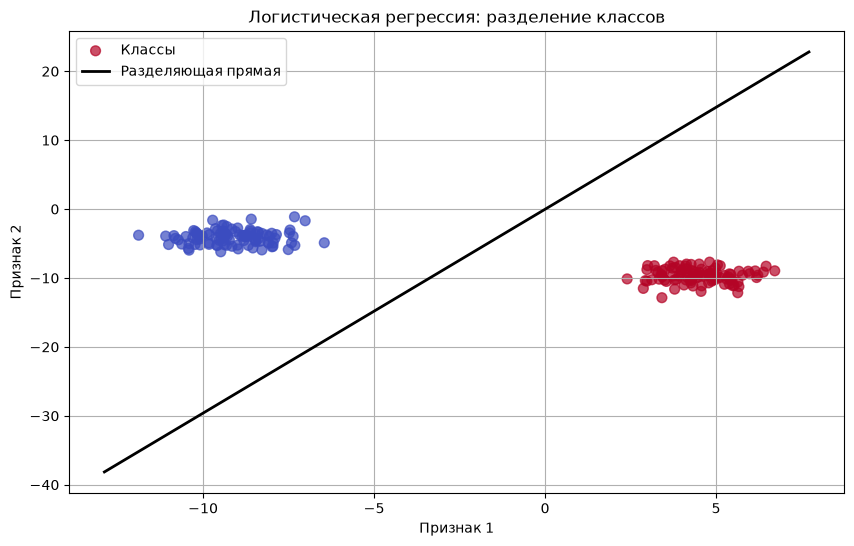

In [53]:
w1, w2 = model.coef_[0]
b = model.intercept_[0]

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1 

x_line = np.linspace(x_min, x_max, 200)
y_line = -(w1 * x_line + b) / w2

plt.figure(figsize=(10, 6))

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=50, alpha=0.7, label="Классы")
plt.plot(x_line, y_line, color="black", linewidth=2, label="Разделяющая прямая")

plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.title("Логистическая регрессия: разделение классов")
plt.legend()
plt.grid()
plt.show()

## Задание 8. Загрузка датасета Fashion-MNIST

Fashion-MNIST — датасет изображений одежды и аксессуаров (28×28 пикселей, 10 классов). Он часто используется
как замена MNIST для оценки алгоритмов классификации.

1. **Загрузи датасет Fashion-MNIST:**
   - Используй `torchvision.datasets.FashionMNIST` (PyTorch).
   - Получи обучающую и тестовую выборки: изображения и метки классов.

2. **Визуализация изображений и классов:**
   - Выведи соответствие «номер класса — название класса».
   - Визуализируй несколько примеров (например, по одному изображению каждого класса или сетку 2×5/5×2): покажи изображение и подпись с названием класса.

In [54]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="../datasets",
    train=True,
    download=True,
    transform=transform
)

test_dataset = test_dataset = torchvision.datasets.FashionMNIST(
    root="../datasets",
    train=False,
    download=True,
    transform=transform
)

print(f"Размер train: {len(train_dataset)}")
print(f"Размер test: {len(test_dataset)}")


100.0%
100.0%
100.0%
100.0%

Размер train: 60000
Размер test: 10000


In [55]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

for i, name in enumerate(class_names):
    print(i, "—", name)

0 — T-shirt/top
1 — Trouser
2 — Pullover
3 — Dress
4 — Coat
5 — Sandal
6 — Shirt
7 — Sneaker
8 — Bag
9 — Ankle boot


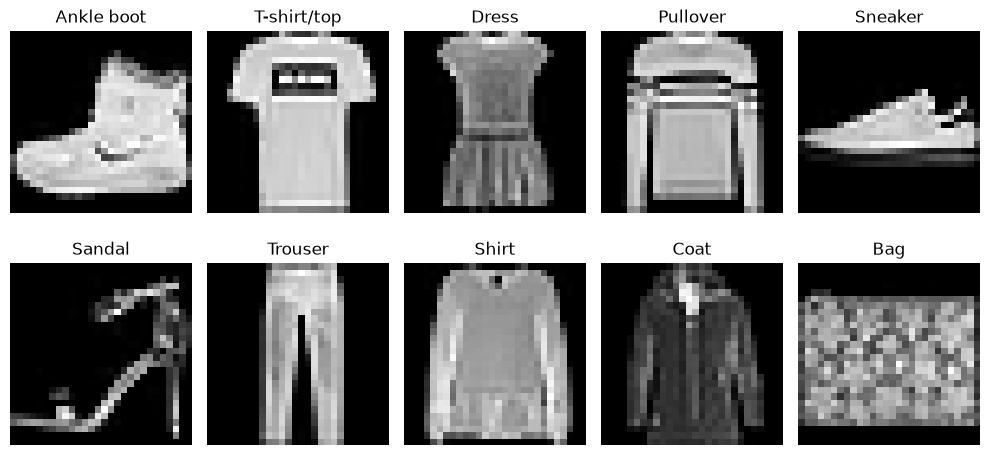

In [56]:
examples = {}
for img, label in train_dataset:
    if label not in examples:
        examples[label] = img
    if len(examples) == 10:
        break

fig, axs = plt.subplots(2, 5, figsize=(10, 5))

for idx, (label, img) in enumerate(examples.items()):
    ax = axs[idx // 5][idx % 5]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

## Задание 9. Классификация одежды

В этом задании ты обучишь логистическую регрессию для многоклассовой классификации изображений Fashion-MNIST
и замеришь качество.

1. **Подготовка данных:**
   - Используй данные, загруженные в Задании 8.
   - Преобразуй изображения в векторы признаков: каждое изображение 28×28 — в вектор длины 784.
   - Раздели данные на обучающую и тестовую выборки.

2. **Обучение модели:**
   - Обучи `LogisticRegression` из `sklearn.linear_model` на обучающей выборке.
   - Используй целевую переменную — метки классов (0–9).

3. **Оценка качества:**
   - На тестовой выборке посчитай точность (`accuracy_score` или `model.score`).
   - Построй и выведи матрицу ошибок (confusion matrix).
   - Выведи отчёт по метрикам `classification_report` из `sklearn.metrics` и проанализируй, по каким классам модель ошибается чаще всего.

In [63]:
images = []
labels = []

for img, label in train_dataset:
    img_flat = img.numpy().reshape(-1) # 28x28 -> 784
    images.append(img_flat)
    labels.append(label)

df = pd.DataFrame(images)
df["label"] = labels

print(df.shape)
df.head()

(60000, 785)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,9
1,0.0,0.0,0.0,0.0,0.0,0.003922,0.0,0.0,0.000000,0.000000,...,0.447059,0.509804,0.298039,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.086275,...,0.000000,0.003922,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.129412,0.376471,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,3
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0


In [64]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='label')
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(
    solver='lbfgs',
    random_state=21
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Точность: {acc}")

Точность: 0.8525


C:\Users\edolg\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


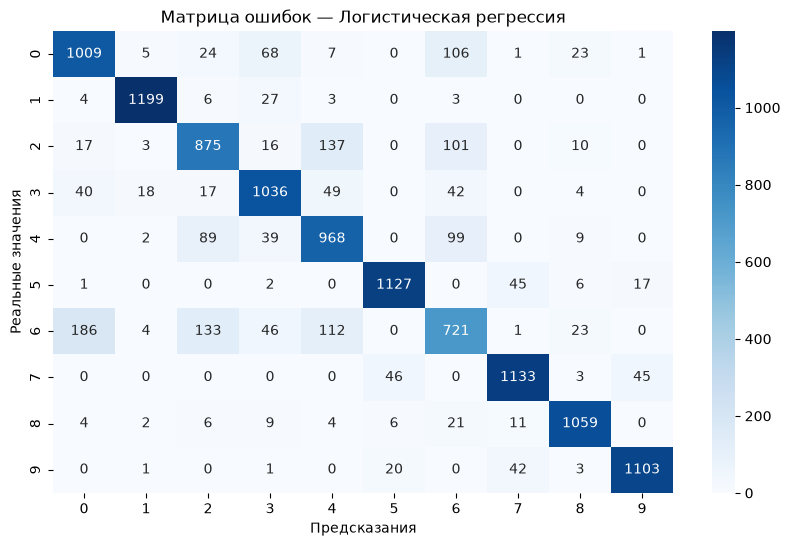

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Матрица ошибок — Логистическая регрессия")
plt.xlabel("Предсказания")
plt.ylabel("Реальные значения")
plt.show()

In [69]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1244
           1       0.97      0.97      0.97      1242
           2       0.76      0.75      0.76      1159
           3       0.83      0.86      0.85      1206
           4       0.76      0.80      0.78      1206
           5       0.94      0.94      0.94      1198
           6       0.66      0.59      0.62      1226
           7       0.92      0.92      0.92      1227
           8       0.93      0.94      0.94      1122
           9       0.95      0.94      0.94      1170

    accuracy                           0.85     12000
   macro avg       0.85      0.85      0.85     12000
weighted avg       0.85      0.85      0.85     12000



Выше представлен отчет по метрикам, из которого видно, что модель логистической регрессии чаще всего ошибается по 2, 4 и 6 классам, так как они имеют самую маленькую точность.

### Бонусные задания. Нейронные сети

Один слой нейронной сети без нелинейной функции активации — это по сути линейная модель: те же веса ${w}$,
свободный член $b$ и формула ${w}^T {x} + b$. Всё, что ты делал с линейной и логистической регрессией,
укладывается в «один линейный слой». Нейросеть становится по-настоящему нелинейной, когда добавляются скрытые слои
и функции активации (ReLU, сигмоида и др.): каждый слой — линейное преобразование, активация «ломает» линейность,
и цепочка таких слоёв позволяет приближать сложные зависимости.

**PyTorch** — популярный фреймворк для машинного обучения и глубокого обучения. В нём модель задаётся как композиция
слоёв, градиенты считаются автоматически (autograd), а обучение идёт итеративно, как в градиентном спуске. PyTorch
удобен для экспериментов и исследований, его часто используют в индустрии. В этих заданиях ты попробуешь реализовать
простые нейросети на PyTorch и применить их к классификации Fashion-MNIST.

![nn](../misc/images/nn.png)

## Задание 10. Линейная регрессия на PyTorch

1. **Построй модель:**
   - Однослойная сеть на PyTorch — линейный классификатор `nn.Linear(784, 10)` без нелинейной активации (или с
     логистикой на выходе).
   - Вход — вектор признаков длины 784 (развёрнутое изображение 28×28), выход — 10 чисел (по одному на класс).

2. **Обучи модель:**
   - Используй градиентный спуск или его вариант (например, SGD/Adam через `torch.optim`).
   - В качестве функции потерь возьми кросс-энтропию (`nn.CrossEntropyLoss`).

3. **Оцени качество:**
   - На тестовой выборке замерь точность классификации.
   - Используй данные из Заданий 8–9 (векторизованные изображения и метки классов).

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train = train_dataset.data.reshape(-1, 28*28).float() / 255.0 # тензор размера (60000, 784)
y_train = train_dataset.targets # (60000, )

X_test = test_dataset.data.reshape(-1, 28*28).float() / 255.0 # (10000, 784)
y_test = test_dataset.targets # (10000, )

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([60000, 784]) torch.Size([60000])
torch.Size([10000, 784]) torch.Size([10000])


In [74]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

In [ ]:
import torch.nn as nn

class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(784, 10)

    def forward(self, x):
        return self.linear(x)

model = LinearClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss:.4f}")

Epoch 1/5, Loss: 605.9052
Epoch 2/5, Loss: 450.8210
Epoch 3/5, Loss: 421.3345
Epoch 4/5, Loss: 406.0940
Epoch 5/5, Loss: 393.3544


In [ ]:
from sklearn.metrics import accuracy_score

model.eval()
preds = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs = model(X_batch)
        preds.append(outputs.argmax(dim=1))

y_pred = torch.cat(preds)

acc = accuracy_score(y_test, y_pred)
print("Точность на тесте:", acc)

Точность на тесте: 0.8402


## Задание 11. Нейронная сеть

1. **Усложни архитектуру:**
   - Добавь один или несколько скрытых слоёв с нелинейной активацией (например, ReLU).
   - Увеличь количество нейронов в скрытых слоях, чтобы модель могла лучше аппроксимировать зависимость между
     признаками и метками.

2. **Обучи и оцени:**
   - Обучи сеть на тех же данных Fashion-MNIST.
   - Замерь точность на тестовой выборке.
   - Сравни результат с однослойной моделью из Задания 10 (улучшилась ли точность, насколько, не возникло ли
     переобучения).

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss:.4f}")

Epoch 1/5, Loss: 490.2720
Epoch 2/5, Loss: 346.7317
Epoch 3/5, Loss: 309.9252
Epoch 4/5, Loss: 287.1789
Epoch 5/5, Loss: 271.0597


In [79]:
from sklearn.metrics import accuracy_score

model.eval()
preds = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs = model(X_batch)
        preds.append(outputs.argmax(dim=1))

y_pred = torch.cat(preds)

acc = accuracy_score(y_test, y_pred)
print("Точность на тесте:", acc)

Точность на тесте: 0.884


По сравнению с заданием 10 многослойная нейросеть дала прирости точности в 4%.

В MLP было добавлено 2 скрытых слоя с нелинейной активацией(ReLU).

Переобучение на Fashion‑MNIST почти не возникает, потому что датасет большой (60k изображений).

## Задание 12. Эксперименты

Попробуй разными способами повысить качество работы модели на Fashion-MNIST.

1. **Что можно менять:**
   - архитектуру сети (число слоёв, число нейронов);
   - функции активации;
   - оптимизатор и learning rate;
   - размер батча, количество эпох.

2. **Что нужно оформить:**
   - Кратко опиши, какие варианты ты попробовал.
   - Сделай небольшой вывод: что сработало лучше и почему, какие идеи тебе кажутся перспективными.

In [ ]:
class MLPupd(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

model = MLPupd()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001)

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss:.4f}")

Epoch 1/50, Loss: 704.1772
Epoch 2/50, Loss: 431.5666
Epoch 3/50, Loss: 387.1692
Epoch 4/50, Loss: 361.8617
Epoch 5/50, Loss: 342.8015
Epoch 6/50, Loss: 325.7042
Epoch 7/50, Loss: 311.2267
Epoch 8/50, Loss: 301.3567
Epoch 9/50, Loss: 288.4372
Epoch 10/50, Loss: 279.0032
Epoch 11/50, Loss: 271.1705
Epoch 12/50, Loss: 261.8645
Epoch 13/50, Loss: 253.3907
Epoch 14/50, Loss: 245.6625
Epoch 15/50, Loss: 237.5830
Epoch 16/50, Loss: 231.0218
Epoch 17/50, Loss: 225.1355
Epoch 18/50, Loss: 219.0883
Epoch 19/50, Loss: 212.0140
Epoch 20/50, Loss: 206.6774
Epoch 21/50, Loss: 201.0640
Epoch 22/50, Loss: 195.8960
Epoch 23/50, Loss: 190.3439
Epoch 24/50, Loss: 186.2994
Epoch 25/50, Loss: 180.3119
Epoch 26/50, Loss: 174.5228
Epoch 27/50, Loss: 169.3406
Epoch 28/50, Loss: 165.2967
Epoch 29/50, Loss: 159.8122
Epoch 30/50, Loss: 155.1705
Epoch 31/50, Loss: 150.9514
Epoch 32/50, Loss: 144.7296
Epoch 33/50, Loss: 142.1185
Epoch 34/50, Loss: 136.4625
Epoch 35/50, Loss: 133.7977
Epoch 36/50, Loss: 128.4774
E

In [81]:
model.eval()
preds = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs = model(X_batch)
        preds.append(outputs.argmax(dim=1))

y_pred = torch.cat(preds)

acc = accuracy_score(y_test, y_pred)
print("Точность на тесте:", acc)

Точность на тесте: 0.8978


В первой итерации улучшения многослойной модели я:

- увеличил количество слоёв нейронной сети с 2-ух до 3-х;
- заменил функцию оптимизации параметров на AdamW, так как она стабильнее, и уменьшил learning rate(lr) до 0.0001;
- и увеличил количесво эпох до 50.

В результате этих улучшений потери значительно уменьшились и точность возросла примерно на 1%

In [85]:
class MLPupd2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

model = MLPupd2()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss:.4f}")

Epoch 1/15, Loss: 506.2674
Epoch 2/15, Loss: 383.3992
Epoch 3/15, Loss: 349.1078
Epoch 4/15, Loss: 330.7677
Epoch 5/15, Loss: 312.6840
Epoch 6/15, Loss: 301.6300
Epoch 7/15, Loss: 287.7543
Epoch 8/15, Loss: 279.9018
Epoch 9/15, Loss: 269.2494
Epoch 10/15, Loss: 262.2510
Epoch 11/15, Loss: 252.6002
Epoch 12/15, Loss: 248.5674
Epoch 13/15, Loss: 241.0872
Epoch 14/15, Loss: 232.6197
Epoch 15/15, Loss: 230.1864


In [86]:
model.eval()
preds = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs = model(X_batch)
        preds.append(outputs.argmax(dim=1))

y_pred = torch.cat(preds)

acc = accuracy_score(y_test, y_pred)
print("Точность на тесте:", acc)

Точность на тесте: 0.8922


В этой итерации я:

- уменьшил количество эпох до 15;
- добавил функции BatchNorm и Dropout для стабилизации и ускорения обучения, а также для снижения переобучения.

При таких улучшениях модель дает точность 89% при `epochs = 15`. В прошлой итерации я достиг этого же значения при `epoch = 50`.

В перспективе увеличение количества эпох может дать прирост точности на 1-3%, поэтому я считаю это способ самым эффективным для улучшения модели.